In [6]:
# ============================================
# 1. 이진분류(Binary Classification) 실습
# 예제 데이터 : breast cancer dataset
# 목표:
# - 이진분류 모델 학습
# - 학습 결과 저장
# - 저장된 모델/스케일러/학습 이력 불러오기
# - 신규 데이터 예측
# - 학습결과 및 예측결과 시각화
# ============================================

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_breast_cancer     # 암진단 데이터 읽어오기
import joblib                                       # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                             # 텐서플로우 lib

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential                   
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [12]:
# ============================================
# 1. 데이터 읽어오기  (유방암 데이터셋)
# ============================================

data = load_breast_cancer()
X = data.data          # 입력 x data
y = data.target        # 타겟 레이블 y 데이터

feature_names = data.feature_names    # 특성 이름
df = pd.DataFrame(X, columns=feature_names)    # 데이터 확인을 데이터프레임으로 변환

df['target'] = y    # 타겟 컬럼을 추가

print('전체 데이터 shape:', df.shape)

전체 데이터 shape: (569, 31)


In [13]:
df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [14]:
# ============================================
# 2. 학습용/테스트용 데이터 분리
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# ============================================
# 3. 스케일링
# ============================================
scaler = StandardScaler()                           # StandardScaler 객체 생성
X_train_scaled = scaler.fit_transform(X_train)      # 학습 데이터 기준으로 평균과 표준편차를 학습하고 반환
X_test_scaled = scaler.transform(X_test)            # 테스트 데이터는 학습 데이터 기준으로 반환

In [16]:
# ============================================
# 4. 모델 정의
# ============================================
model = Sequential()                      # 순차형 신경망 모델 생성
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))      # 첫 번째 은닉층 추가 
model.add(Dropout(0.2))                                                              # 과적합 방지를 위해 드롭아웃 적용 20%

model.add(Dense(32, activation='relu'))                                              # 두 번째 은닉층 추가
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))                                           # 이진분류이므로 출력층 노드 1개와 sigmoid 활성화 함수 사용

model.summary()   # 모델 구조 출력

D:\anaconda3\envs\ai\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                     │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ============================================
# 5. 모델 컴파일
# ============================================

# 손실함수는 binary crossentropy, 평가지표는 accuracy를 사용
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [21]:
# ============================================
# 6. 모델 학습
# ============================================

# 모델을 학습하고, history 객체에 학습 과정을 저장
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6538 - loss: 0.7068 - val_accuracy: 0.8242 - val_loss: 0.4788
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8626 - loss: 0.4224 - val_accuracy: 0.9451 - val_loss: 0.3072
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9341 - loss: 0.2797 - val_accuracy: 0.9451 - val_loss: 0.2263
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9505 - loss: 0.2156 - val_accuracy: 0.9560 - val_loss: 0.1778
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9396 - loss: 0.1914 - val_accuracy: 0.9560 - val_loss: 0.1455
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9588 - loss: 0.1466 - val_accuracy: 0.9780 - val_loss: 0.1217
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9643 - loss: 0.1312 - val_accuracy: 0.9780 - val_loss: 0.1057
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9670 - loss: 0.1255 - val_accuracy: 0.9780 

In [22]:
# ============================================
# 7. 모델 평가
# ============================================

# 테스트 데이터에 대해 손실과 정확도 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

# 평가 결과 출력
print('테스트 손실: ', test_loss)
print('테스트 정확도: ', test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

# 확률을 0 또는 1 클래스로 변환
y_pred = (y_prob >= 0.5).astype(int).flatten()

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion matrix 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print('정확도:', acc)
print('confusion matrix: \n', cm)
print('분류 리포트 :\n', classification_report(y_test, y_pred))

    


테스트 손실:  0.12111573666334152
테스트 정확도:  0.9561403393745422
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
정확도: 0.956140350877193
confusion matrix: 
 [[41  1]
 [ 4 68]]
분류 리포트 :
               precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [24]:
# ============================================
# 8. 학습결과 저장
# ============================================

# 모델을 파일로 저장
model.save('./results/Binary_Classification.h5')   # 또는 'Binary_Classification.keras'

# 스케일러를 파일로 저장
joblib.dump(scaler, './results/Binary_Classification.pkl')

# 학습이력을 데이터프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습이력을 csv파일로 저장
history_df.to_csv('./results/Binary_Classification.csv', index=False)

# 저장 완료 메세지 출력
print("이진분류 모델 , 스케일러, 학습이력 저장 완료")

이진분류 모델 , 스케일러, 학습이력 저장 완료


In [25]:
# ============================================
# 9. 저장된 결과 읽어오기
# ============================================
# 저장된 모델을 다시 불러오기
loaded_model = tf.keras.models.load_model('./results/Binary_Classification.h5')

# 저장된 스케일러를 다시 불러오기
loaded_scaler = joblib.load('./results/Binary_Classification.pkl')

In [27]:
# ============================================
# 10. 신규 데이터 예측
# ============================================

# 학습하지 않은 테스트데이터 중 첫 5개를 신규 데이터로 예측 수행
new_data = X_test[:5]

# 신규 데이터를 스케일링 처리
new_data_scaled = loaded_scaler.transform(new_data)

# 신규 데이터의 예측 확률 계산
new_prob = loaded_model.predict(new_data_scaled)

# 예측 확률값을 0/1로 변환
new_pred = (new_prob >= 0.5).astype(int).flatten()

# 결과출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측확률: {new_prob[i][0]:.4f}, 예측클래스: {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1번 샘플 - 예측확률: 0.0000, 예측클래스: 0
2번 샘플 - 예측확률: 1.0000, 예측클래스: 1
3번 샘플 - 예측확률: 0.0000, 예측클래스: 0
4번 샘플 - 예측확률: 0.2208, 예측클래스: 0
5번 샘플 - 예측확률: 0.0000, 예측클래스: 0


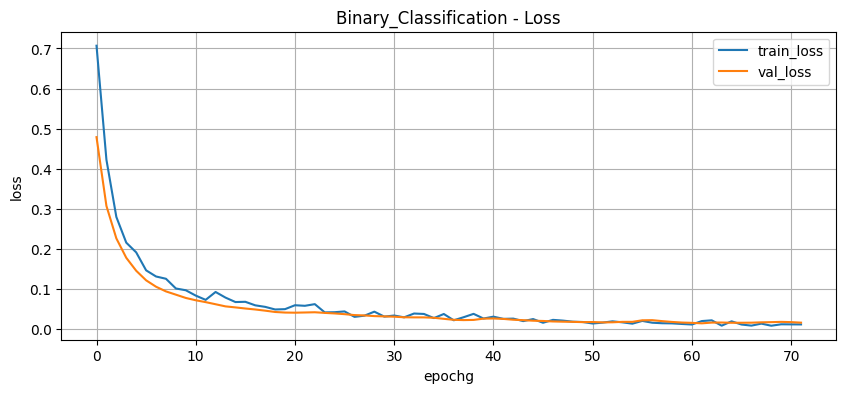

In [28]:
# ============================================
# 11. 시각화 결과 확인
# ============================================

# 학습 loss 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Binary_Classification - Loss')
plt.xlabel('epochg')
plt.ylabel('loss')
plt.legend()
plt.grid(True)     # 그래프를 격자로 표시
plt.show()


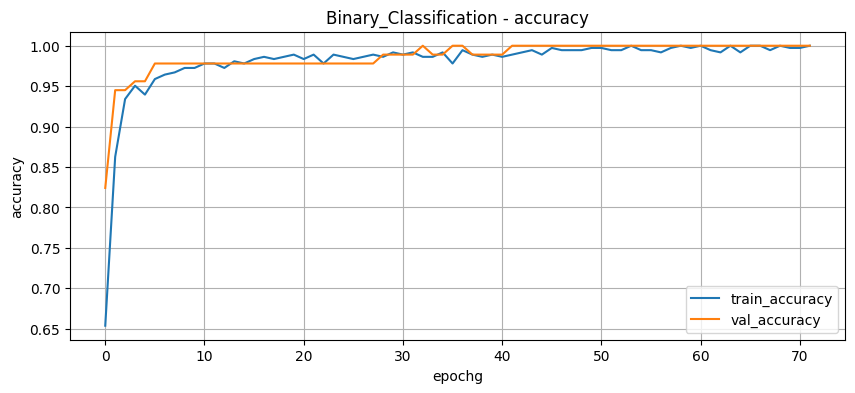

In [29]:
# 학습 정확도 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Binary_Classification - accuracy')
plt.xlabel('epochg')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)     # 그래프를 격자로 표시
plt.show()

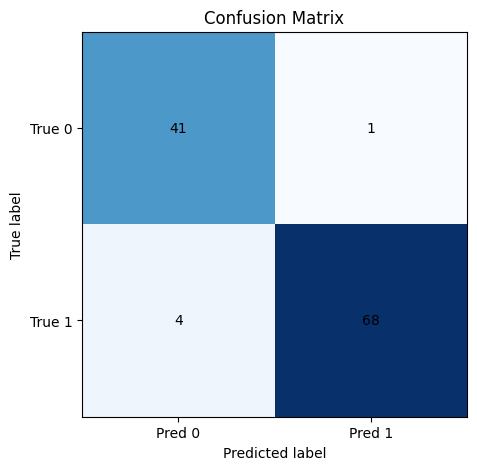

In [31]:
# confusion matrix 시각화
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')

# x축과 y축 눈금 설정
plt.xticks([0,1], ['Pred 0', 'Pred 1'])
plt.yticks([0,1], ['True 0', 'True 1'])

# CM 내부에 숫자 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


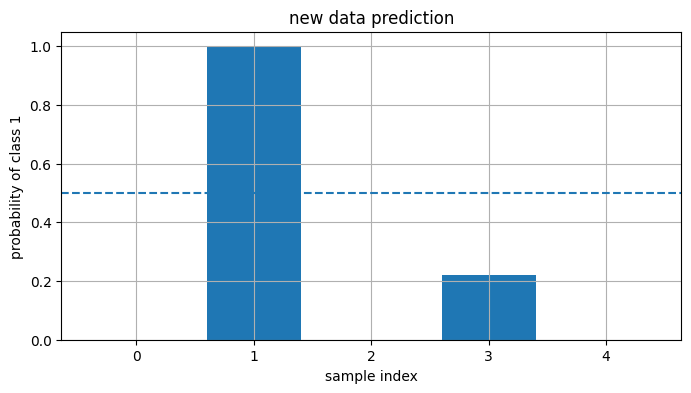

In [33]:
# 신규 데이터 예측 결과 시각화

new_prob_flat = new_prob.flatten()

plt.figure(figsize=(8,4))
plt.bar(range(len(new_prob_flat)), new_prob_flat)

# 기준선 0.5로 표시
plt.axhline(0.5, linestyle="--")

plt.title('new data prediction')
plt.xlabel('sample index')
plt.ylabel('probability of class 1')

plt.grid(True)
plt.show()